# POC — From-scratch pretraining vs. multilingual transfer

Proof-of-concept for the proposal *"Is Pretraining Still Worth It?"*

This notebook is **not** the experiment. It is a sequence of **gates**, each testing a
specific project risk.

| Gate | Question | If it fails |
|---|---|---|
| 1 | Does the downstream data load, and does a pretrained baseline fine-tune cleanly? | Fix the eval harness before anything else |
| 2 | Can we pretrain a from-scratch encoder with a masked-LM objective? | The new-objective risk is real; budget for it |
| 3 | **Does the checkpoint bridge work?** | This is the project's largest integration risk |
| 4 | Do both model types produce comparable numbers through one harness? | Redesign the interface |

**Gate 3 is the important one.** The proposal's biggest risk is that from-scratch models
live in one framework and pretrained baselines in another, with a fragile conversion
between them. This notebook demonstrates the fix: **build the from-scratch model through a
HuggingFace config object from the start.** Then `save_pretrained` and
`from_pretrained` work natively and there is no bridge to build at all.

**Runtime:** roughly 25–40 min on a free T4.
**Runtime → Change runtime type → GPU** before you start.

In [1]:
#@title Setup
%pip install -q -U datasets transformers tokenizers 2>/dev/null

import os, time, math, json, random, shutil
import numpy as np
import torch, torch.nn as nn, torch.nn.functional as F

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("torch", torch.__version__, "| device:", DEVICE)
if DEVICE.type == "cuda":
    print("gpu  :", torch.cuda.get_device_name(0))
else:
    print("WARNING: no GPU. Runtime > Change runtime type > GPU.")

import transformers
print("transformers", transformers.__version__)

def set_seed(s):
    random.seed(s); np.random.seed(s); torch.manual_seed(s); torch.cuda.manual_seed_all(s)

set_seed(0)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.0/559.1 kB ? eta -:--:--
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 559.1/559.1 kB 25.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 202.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 MB 66.8 MB/s eta 0:00:00
torch 2.11.0+cu128 | device: cuda
gpu  : NVIDIA RTX PRO 6000 Blackwell Server Edition
transformers 5.14.1


In [2]:
#@title Configuration — edit here
LANG          = "swh_Latn"      # target language (FLORES/SIB-200 style code)
WIKI_CODE     = "sw"            # same language, Wikipedia code (fallback corpus)

BASELINES = [
    "FacebookAI/xlm-roberta-base",
    "jhu-clsp/mmBERT-base",      # optional; skipped automatically if unavailable
]

TARGET_CHARS  = 20_000_000      # raw text to stream for pretraining
VOCAB_SIZE    = 8_000
MAX_LEN       = 128

# From-scratch pretraining ladder (tiny, for the POC only)
PRETRAIN_LADDER = [1_000_000, 4_000_000]   # tokens
PRETRAIN_STEPS  = 1200
MLM_PROB        = 0.15

# Downstream fine-tuning
FT_EPOCHS     = 8
FT_BATCH      = 16
FT_LR         = 2e-5
FT_LR_SCRATCH = 5e-5            # from-scratch models tolerate (and need) a higher LR

---
## Gate 1 — Downstream data and a pretrained baseline

SIB-200 is derived from FLORES-200, so the same sentences appear in every language. That
parallel structure removes content as a confound, and — since nobody on the team speaks the
target languages — it means any misclassified item can be read in English.

We fine-tune with a plain PyTorch loop rather than `Trainer`, deliberately: the `Trainer`
argument names have churned across releases, and a POC that breaks on a library upgrade is
worse than useless.

In [3]:
#@title Load SIB-200
from datasets import load_dataset, get_dataset_config_names

SIB_CANDIDATES = ["Davlan/sib200", "mteb/sib200"]
sib, sib_repo = None, None
for repo in SIB_CANDIDATES:
    try:
        sib = load_dataset(repo, LANG)
        sib_repo = repo
        break
    except Exception as e:
        print(f"[{repo}] failed: {repr(e)[:140]}")

if sib is None:
    raise RuntimeError("SIB-200 did not load. Check the language code against:\n"
                       "  get_dataset_config_names('Davlan/sib200')")

print(f"\nloaded {sib_repo} / {LANG}")
print(sib)
cols = sib["train"].column_names
print("columns:", cols)

TEXT_COL  = next(c for c in ["text", "sentence"] if c in cols)
LABEL_COL = next(c for c in ["category", "label", "labels"] if c in cols)
labels = sorted(set(sib["train"][LABEL_COL]))
L2I = {l: i for i, l in enumerate(labels)}
NUM_LABELS = len(labels)
EVAL_SPLIT = "test" if "test" in sib else ("validation" if "validation" in sib else "train")
print(f"text column '{TEXT_COL}', label column '{LABEL_COL}', {NUM_LABELS} labels: {labels}")
print(f"evaluating on the '{EVAL_SPLIT}' split "
      f"({len(sib['train'])} train / {len(sib[EVAL_SPLIT])} eval examples)")
print(f"\nexample: {sib['train'][0][TEXT_COL][:200]}")

README.md:   0%|          | 0.00/47.9k [00:00<?, ?B/s]

train.tsv:   0%|          | 0.00/108k [00:00<?, ?B/s]

dev.tsv:   0%|          | 0.00/14.6k [00:00<?, ?B/s]

test.tsv:   0%|          | 0.00/31.5k [00:00<?, ?B/s]

Generating train split: 0 examples [00:00, ? examples/s]

Generating validation split: 0 examples [00:00, ? examples/s]

Generating test split: 0 examples [00:00, ? examples/s]


loaded Davlan/sib200 / swh_Latn
DatasetDict({
    train: Dataset({
        features: ['index_id', 'category', 'text'],
        num_rows: 701
    })
    validation: Dataset({
        features: ['index_id', 'category', 'text'],
        num_rows: 99
    })
    test: Dataset({
        features: ['index_id', 'category', 'text'],
        num_rows: 204
    })
})
columns: ['index_id', 'category', 'text']
text column 'text', label column 'category', 7 labels: ['entertainment', 'geography', 'health', 'politics', 'science/technology', 'sports', 'travel']
evaluating on the 'test' split (701 train / 204 eval examples)

example: Uturuki imezungukwa na maziwa katika pande tatu: Bahari ya Aegea upande wa magharibi, Bahari Nyeusi upande wa kaskazini na Bahari ya Mediterania upande wa kusini.


In [4]:
#@title Shared fine-tuning + evaluation harness
from transformers import AutoTokenizer, AutoModelForSequenceClassification

def encode_split(split, tokenizer, max_len=MAX_LEN):
    enc = tokenizer([r for r in sib[split][TEXT_COL]], truncation=True,
                    max_length=max_len, padding="max_length", return_tensors="pt")
    y = torch.tensor([L2I[l] for l in sib[split][LABEL_COL]])
    return torch.utils.data.TensorDataset(enc["input_ids"], enc["attention_mask"], y)

def macro_f1(y_true, y_pred, k):
    f1s = []
    for c in range(k):
        tp = ((y_pred == c) & (y_true == c)).sum().item()
        fp = ((y_pred == c) & (y_true != c)).sum().item()
        fn = ((y_pred != c) & (y_true == c)).sum().item()
        p = tp / (tp + fp) if tp + fp else 0.0
        r = tp / (tp + fn) if tp + fn else 0.0
        f1s.append(2 * p * r / (p + r) if p + r else 0.0)
    return float(np.mean(f1s))

def finetune_and_eval(model_path, tokenizer_path=None, lr=FT_LR, epochs=FT_EPOCHS,
                      seed=0, label=""):
    '''Fine-tune ANY checkpoint path on SIB-200 and return macro-F1 on the eval split.

    The whole point: this function does not know or care whether model_path is an
    off-the-shelf pretrained encoder or something we pretrained ourselves ten minutes ago.
    '''
    set_seed(seed)
    tok = AutoTokenizer.from_pretrained(tokenizer_path or model_path)
    try:
        model = AutoModelForSequenceClassification.from_pretrained(
            model_path, num_labels=NUM_LABELS).to(DEVICE)
    except Exception as e:
        # ModernBERT-family models (mmBERT) default to FlashAttention-2, which needs
        # Ampere or newer -- a free-tier T4 is Turing and will fail here. SDPA works.
        print(f"  default load failed ({repr(e)[:90]}); retrying with attn_implementation='sdpa'")
        model = AutoModelForSequenceClassification.from_pretrained(
            model_path, num_labels=NUM_LABELS, attn_implementation="sdpa").to(DEVICE)

    tr = torch.utils.data.DataLoader(encode_split("train", tok), batch_size=FT_BATCH,
                                     shuffle=True, drop_last=False)
    te = torch.utils.data.DataLoader(encode_split(EVAL_SPLIT, tok), batch_size=64)

    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=0.01)
    total = max(1, len(tr) * epochs)
    sched = torch.optim.lr_scheduler.OneCycleLR(opt, max_lr=lr, total_steps=total,
                                                pct_start=0.1)
    t0 = time.time()
    model.train()
    for ep in range(epochs):
        for ids, am, y in tr:
            ids, am, y = ids.to(DEVICE), am.to(DEVICE), y.to(DEVICE)
            out = model(input_ids=ids, attention_mask=am).logits
            loss = F.cross_entropy(out, y)
            opt.zero_grad(set_to_none=True)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step(); sched.step()

    model.eval()
    preds, gold = [], []
    with torch.no_grad():
        for ids, am, y in te:
            p = model(input_ids=ids.to(DEVICE), attention_mask=am.to(DEVICE)).logits.argmax(-1)
            preds.append(p.cpu()); gold.append(y)
    preds, gold = torch.cat(preds), torch.cat(gold)
    f1 = macro_f1(gold, preds, NUM_LABELS)
    acc = (preds == gold).float().mean().item()
    print(f"  {label or model_path}: macro-F1 {f1:.3f} | acc {acc:.3f} "
          f"| {time.time()-t0:.0f}s")
    del model; torch.cuda.empty_cache()
    return f1

In [5]:
#@title Fine-tune the pretrained baselines
# NOTE: 'Some weights ... newly initialized: classifier.*' is expected and correct --
# the classification head does not exist in a pretrained encoder checkpoint.
baseline_scores = {}
for name in BASELINES:
    print(f"\n{name}")
    try:
        baseline_scores[name] = finetune_and_eval(name, label=name.split('/')[-1])
    except Exception as e:
        print(f"  SKIPPED: {repr(e)[:200]}")

if not baseline_scores:
    raise RuntimeError("No baseline fine-tuned successfully -- fix this before proceeding.")
print("\nbaselines:", {k.split('/')[-1]: round(v, 3) for k, v in baseline_scores.items()})


FacebookAI/xlm-roberta-base


config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.10M [00:00<?, ?B/s]

...

Loading weights:   0%|          | 0/136 [00:00<?, ?it/s]

[transformers] ModernBertForSequenceClassification LOAD REPORT from: jhu-clsp/mmBERT-base
Key               | Status     | 
------------------+------------+-
decoder.weight    | UNEXPECTED | 
decoder.bias      | UNEXPECTED | 
classifier.bias   | MISSING    | 
classifier.weight | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


model.safetensors: reconstructing file:   0%|          |  0.00B / 1.23GB            

model.safetensors: downloading bytes:           |  0.00B            

  mmBERT-base: macro-F1 0.791 | acc 0.804 | 21s

baselines: {'xlm-roberta-base': 0.799, 'mmBERT-base': 0.791}


---
## Gate 2 — From-scratch pretraining, built HF-native

The key design decision. Rather than writing a custom encoder class and later converting
its checkpoints, we construct the model from a `RobertaConfig`. It is the same architecture
either way, but this version saves and loads through the standard interface, so Gate 3
becomes trivial instead of being a week of integration work.

In [6]:
#@title Stream a pretraining corpus
def stream_text(lang_code, wiki_code, target_chars=TARGET_CHARS, max_seconds=240):
    attempts = [("fineweb-2", lambda: load_dataset("HuggingFaceFW/fineweb-2", name=lang_code,
                                                   split="train", streaming=True))]
    if wiki_code:
        attempts.append(("wikipedia", lambda: load_dataset(
            "wikimedia/wikipedia", f"20231101.{wiki_code}", split="train", streaming=True)))
    last = None
    for name, opener in attempts:
        try:
            ds = opener(); buf, n, t0 = [], 0, time.time()
            for rec in ds:
                t = rec.get("text") or ""
                if not t:
                    continue
                buf.append(t); n += len(t)
                if n >= target_chars or time.time() - t0 > max_seconds:
                    break
            if n < target_chars * 0.05:
                raise RuntimeError(f"only {n:,} chars")
            print(f"  [{name}] {n:,} chars in {time.time()-t0:.0f}s")
            return "\n".join(buf)
        except Exception as e:
            last = e; print(f"  [{name}] failed: {repr(e)[:120]}")
    raise RuntimeError(f"no corpus source worked: {last}")

print(f"Streaming pretraining text for {LANG} ...")
raw_text = stream_text(LANG, WIKI_CODE)
print("\n--- sample (READ THIS) ---")
print(raw_text[:500].replace("\n", " "))

Streaming pretraining text for swh_Latn ...


README.md:   0%|          | 0.00/329k [00:00<?, ?B/s]

  [fineweb-2] 20,005,347 chars in 2s

--- sample (READ THIS) ---
Let your graceful words fly out into the World, carried on winds of courage, imagination and joy. Let them inspire others to step into action Toba, Sikujua CV inapima IQ ! Huyu ndiye aliyeenda shule mwenye wageni majununi, wenzangunamie kina Maimuna sijui watakuwaje. Kwa wale mnaotaka kuiona picha yake nendeni kwenye hii site. http://www.darhotwire.com/maisha/new...a_na_mpya.html au http://www.globalpublisherstz.com Alafu kwenye tafuta andika manka mushi. Kuna picha kama 3 nzuri hivi alizopiga a


In [7]:
#@title Train a tokenizer and save it in HF format
from tokenizers import Tokenizer, models, trainers, pre_tokenizers, decoders, processors
from transformers import PreTrainedTokenizerFast

SPECIALS = ["<s>", "<pad>", "</s>", "<unk>", "<mask>"]

tok_core = Tokenizer(models.BPE(unk_token="<unk>"))
tok_core.pre_tokenizer = pre_tokenizers.ByteLevel(add_prefix_space=True)
tok_core.decoder = decoders.ByteLevel()
trainer = trainers.BpeTrainer(vocab_size=VOCAB_SIZE, show_progress=False,
                              initial_alphabet=pre_tokenizers.ByteLevel.alphabet(),
                              special_tokens=SPECIALS)
t0 = time.time()
tok_core.train_from_iterator(
    (raw_text[i:i+200_000] for i in range(0, len(raw_text), 200_000)), trainer)
tok_core.post_processor = processors.TemplateProcessing(
    single="<s> $A </s>", pair="<s> $A </s> </s> $B </s>",
    special_tokens=[("<s>", tok_core.token_to_id("<s>")),
                    ("</s>", tok_core.token_to_id("</s>"))])
print(f"BPE trained in {time.time()-t0:.0f}s, vocab {tok_core.get_vocab_size()}")

TOK_DIR = "/content/tok_scratch"
hf_tok = PreTrainedTokenizerFast(
    tokenizer_object=tok_core, bos_token="<s>", eos_token="</s>", unk_token="<unk>",
    pad_token="<pad>", mask_token="<mask>", cls_token="<s>", sep_token="</s>",
    model_max_length=MAX_LEN)
os.makedirs(TOK_DIR, exist_ok=True)
hf_tok.save_pretrained(TOK_DIR)
print("saved tokenizer ->", TOK_DIR)

all_ids = np.array(tok_core.encode(raw_text).ids, dtype=np.int32)
print(f"{len(all_ids):,} tokens ({len(all_ids)/1e6:.2f}M)")
PRETRAIN_LADDER = [n for n in PRETRAIN_LADDER if n <= len(all_ids) * 0.9] or [len(all_ids)//2]
print("pretraining ladder:", PRETRAIN_LADDER)

BPE trained in 2s, vocab 8000
saved tokenizer -> /content/tok_scratch
4,883,724 tokens (4.88M)
pretraining ladder: [1000000, 4000000]


In [8]:
#@title Masked-LM pretraining
from transformers import RobertaConfig, AutoModelForMaskedLM

MASK_ID = hf_tok.mask_token_id
PAD_ID  = hf_tok.pad_token_id

def mask_batch(x, vocab, prob=MLM_PROB):
    '''Standard BERT masking: 15% selected; of those 80% -> <mask>, 10% random, 10% kept.'''
    labels = x.clone()
    sel = torch.rand(x.shape, device=x.device) < prob
    sel &= (x != PAD_ID)
    labels[~sel] = -100                      # ignored by cross-entropy
    r = torch.rand(x.shape, device=x.device)
    x = x.clone()
    x[sel & (r < 0.8)] = MASK_ID
    rnd = torch.randint(len(SPECIALS), vocab, x.shape, device=x.device)
    swap = sel & (r >= 0.8) & (r < 0.9)
    x[swap] = rnd[swap]
    return x, labels

def pretrain(n_tokens, steps=PRETRAIN_STEPS, batch=32, seed=0):
    set_seed(seed)
    V = tok_core.get_vocab_size()
    cfg = RobertaConfig(vocab_size=V, hidden_size=384, num_hidden_layers=6,
                        num_attention_heads=6, intermediate_size=1536,
                        max_position_embeddings=MAX_LEN + 2, type_vocab_size=1,
                        pad_token_id=PAD_ID, bos_token_id=hf_tok.bos_token_id,
                        eos_token_id=hf_tok.eos_token_id)
    model = AutoModelForMaskedLM.from_config(cfg).to(DEVICE)
    n_par = sum(p.numel() for p in model.parameters())
    print(f"  model {n_par/1e6:.1f}M params | corpus {n_tokens/1e6:.2f}M tokens")

    stream = torch.from_numpy(all_ids[:n_tokens].astype(np.int64)).to(DEVICE)
    gen = torch.Generator(device=DEVICE); gen.manual_seed(seed)

    opt = torch.optim.AdamW(model.parameters(), lr=5e-4, weight_decay=0.01)
    sched = torch.optim.lr_scheduler.OneCycleLR(opt, max_lr=5e-4, total_steps=steps,
                                                pct_start=0.1)
    scaler = torch.amp.GradScaler(enabled=(DEVICE.type == "cuda"))
    model.train(); t0 = time.time()
    for step in range(1, steps + 1):
        starts = torch.randint(0, len(stream) - MAX_LEN - 1, (batch,),
                               device=DEVICE, generator=gen)
        pos = starts.view(-1, 1) + torch.arange(MAX_LEN, device=DEVICE)
        x = stream[pos]
        xm, y = mask_batch(x, cfg.vocab_size)
        with torch.autocast("cuda", dtype=torch.float16, enabled=(DEVICE.type == "cuda")):
            out = model(input_ids=xm, labels=y)
        opt.zero_grad(set_to_none=True)
        scaler.scale(out.loss).backward()
        scaler.unscale_(opt)
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler.step(opt); scaler.update(); sched.step()
        if step % 300 == 0 or step == steps:
            print(f"    step {step:>5}  mlm_loss {out.loss.item():.3f}")

    out_dir = f"/content/scratch_{n_tokens}"
    if os.path.exists(out_dir):
        shutil.rmtree(out_dir)
    model.save_pretrained(out_dir)
    hf_tok.save_pretrained(out_dir)
    print(f"  saved -> {out_dir}  ({time.time()-t0:.0f}s)")
    del model; torch.cuda.empty_cache()
    return out_dir

scratch_paths = {}
for n in PRETRAIN_LADDER:
    print(f"\npretraining on {n:,} tokens")
    scratch_paths[n] = pretrain(n)


pretraining on 1,000,000 tokens
  model 13.9M params | corpus 1.00M tokens
    step   300  mlm_loss 6.972
    step   600  mlm_loss 6.386
    step   900  mlm_loss 6.604
    step  1200  mlm_loss 6.540


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  saved -> /content/scratch_1000000  (9s)

pretraining on 4,000,000 tokens
  model 13.9M params | corpus 4.00M tokens
    step   300  mlm_loss 6.953
    step   600  mlm_loss 6.696
    step   900  mlm_loss 6.524
    step  1200  mlm_loss 6.612


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  saved -> /content/scratch_4000000  (9s)


---
## Gate 3 — The checkpoint bridge

The moment of truth. We now feed our own from-scratch checkpoints into **the exact same
`finetune_and_eval` function** used for the pretrained baselines — no conversion, no shim,
no special-casing.

If this cell runs, the proposal's largest integration risk is retired on day one.

**Note on the MLM loss:** a from-scratch model trained for ~1200 steps on a few million
tokens is barely trained. Expect low F1. That is not a failure of the bridge — the bridge
is what is being tested here, and low numbers on the left end of a scaling curve are data.

In [9]:
#@title Fine-tune the from-scratch checkpoints through the same harness
scratch_scores = {}
for n, path in scratch_paths.items():
    print(f"\nfrom-scratch @ {n:,} tokens")
    scratch_scores[n] = finetune_and_eval(path, lr=FT_LR_SCRATCH,
                                          label=f"scratch-{n//1000}k")

print("\nBRIDGE TEST PASSED -- from-scratch and pretrained checkpoints both evaluated "
      "through one code path.")


from-scratch @ 1,000,000 tokens


Loading weights:   0%|          | 0/101 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: /content/scratch_1000000
Key                        | Status     | 
---------------------------+------------+-
lm_head.dense.bias         | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
classifier.dense.bias      | MISSING    | 
classifier.out_proj.weight | MISSING    | 
classifier.out_proj.bias   | MISSING    | 
classifier.dense.weight    | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  scratch-1000k: macro-F1 0.272 | acc 0.392 | 3s

from-scratch @ 4,000,000 tokens


Loading weights:   0%|          | 0/101 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: /content/scratch_4000000
Key                        | Status     | 
---------------------------+------------+-
lm_head.dense.bias         | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
classifier.dense.bias      | MISSING    | 
classifier.out_proj.weight | MISSING    | 
classifier.out_proj.bias   | MISSING    | 
classifier.dense.weight    | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  scratch-4000k: macro-F1 0.328 | acc 0.402 | 3s

BRIDGE TEST PASSED -- from-scratch and pretrained checkpoints both evaluated through one code path.


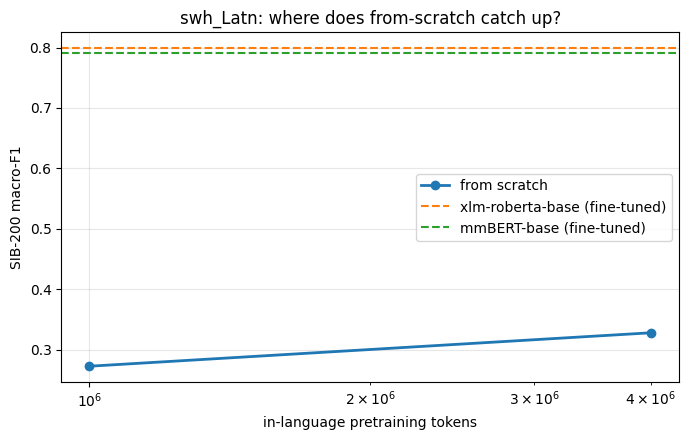

best baseline macro-F1: 0.799
best from-scratch:      0.328  at 4,000,000 tokens

At POC scale the gap should be large. The real study extends the x-axis by roughly two orders of magnitude and asks where -- or whether -- the lines meet.


In [10]:
#@title Plot: from-scratch curve vs pretrained baselines
import matplotlib.pyplot as plt

xs = sorted(scratch_scores)
ys = [scratch_scores[n] for n in xs]

plt.figure(figsize=(7, 4.5))
plt.plot(xs, ys, "o-", lw=2, label="from scratch")
for i, (name, f1) in enumerate(baseline_scores.items()):
    plt.axhline(f1, ls="--", lw=1.5, color=f"C{i+1}",
                label=f"{name.split('/')[-1]} (fine-tuned)")
plt.xscale("log")
plt.xlabel("in-language pretraining tokens")
plt.ylabel("SIB-200 macro-F1")
plt.title(f"{LANG}: where does from-scratch catch up?")
plt.legend(); plt.grid(alpha=.3); plt.tight_layout(); plt.show()

best_base = max(baseline_scores.values())
print(f"best baseline macro-F1: {best_base:.3f}")
print(f"best from-scratch:      {max(ys):.3f}  at {xs[int(np.argmax(ys))]:,} tokens")
print("\nAt POC scale the gap should be large. The real study extends the x-axis by "
      "roughly two orders of magnitude and asks where -- or whether -- the lines meet.")

---
## What this told you

1. **Did SIB-200 load, and did a baseline fine-tune cleanly?** If not, nothing downstream
   is trustworthy. Fix first.
2. **Did mmBERT load?** It is the model whose per-language training exposure is published,
   which is what makes the proposal's ambitious goal testable. If it needs a newer
   `transformers` or extra arguments, find that out now.
3. **Did the bridge work?** This was the point of the notebook. If the same function
   handled both model types, the two-codebase risk is largely gone.
4. **How long did pretraining take per million tokens?** Extrapolate to the real ladder
   (up to 128M tokens) and check that against your calendar and hardware.
5. **Was the streamed text actually the target language?** Low-resource web corpora are
   frequently misidentified.

### What to change for the real study

- Scale pretraining by orders of magnitude — 1200 steps is a smoke test, not pretraining.
  Match total tokens seen, not steps, when comparing ladder rungs.
- Add a validation split for MLM loss so you can tell an undertrained model from a broken
  one.
- **Reproduce a published benchmark number** (e.g. a MasakhaNER 2.0 baseline) before
  trusting any comparison. Without an external anchor you cannot distinguish "this approach
  doesn't work" from "we have a bug" — and with three people working asynchronously, that
  ambiguity is where the time goes.
- Three seeds per downstream cell, fixed step budget, no early stopping (the smallest
  conditions have no dev set to stop on).
- Report GPU-hours alongside token counts, so the answer is about budget and not only data.